In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [45]:
import pandas as pd

series = pd.read_csv('/content/drive/MyDrive/phenoCrops/NDVI_series.csv')
metrics = pd.read_csv('/content/drive/MyDrive/phenoCrops/ndvi_metrics.csv')

In [46]:
series["date"] = pd.to_datetime(series["date"])

metrics["SOS_date"] = pd.to_datetime(metrics["SOS_date"])
metrics["POS_date"] = pd.to_datetime(metrics["POS_date"])
metrics["EOS_date"] = pd.to_datetime(metrics["EOS_date"])

In [47]:
series = series.sort_values("date")

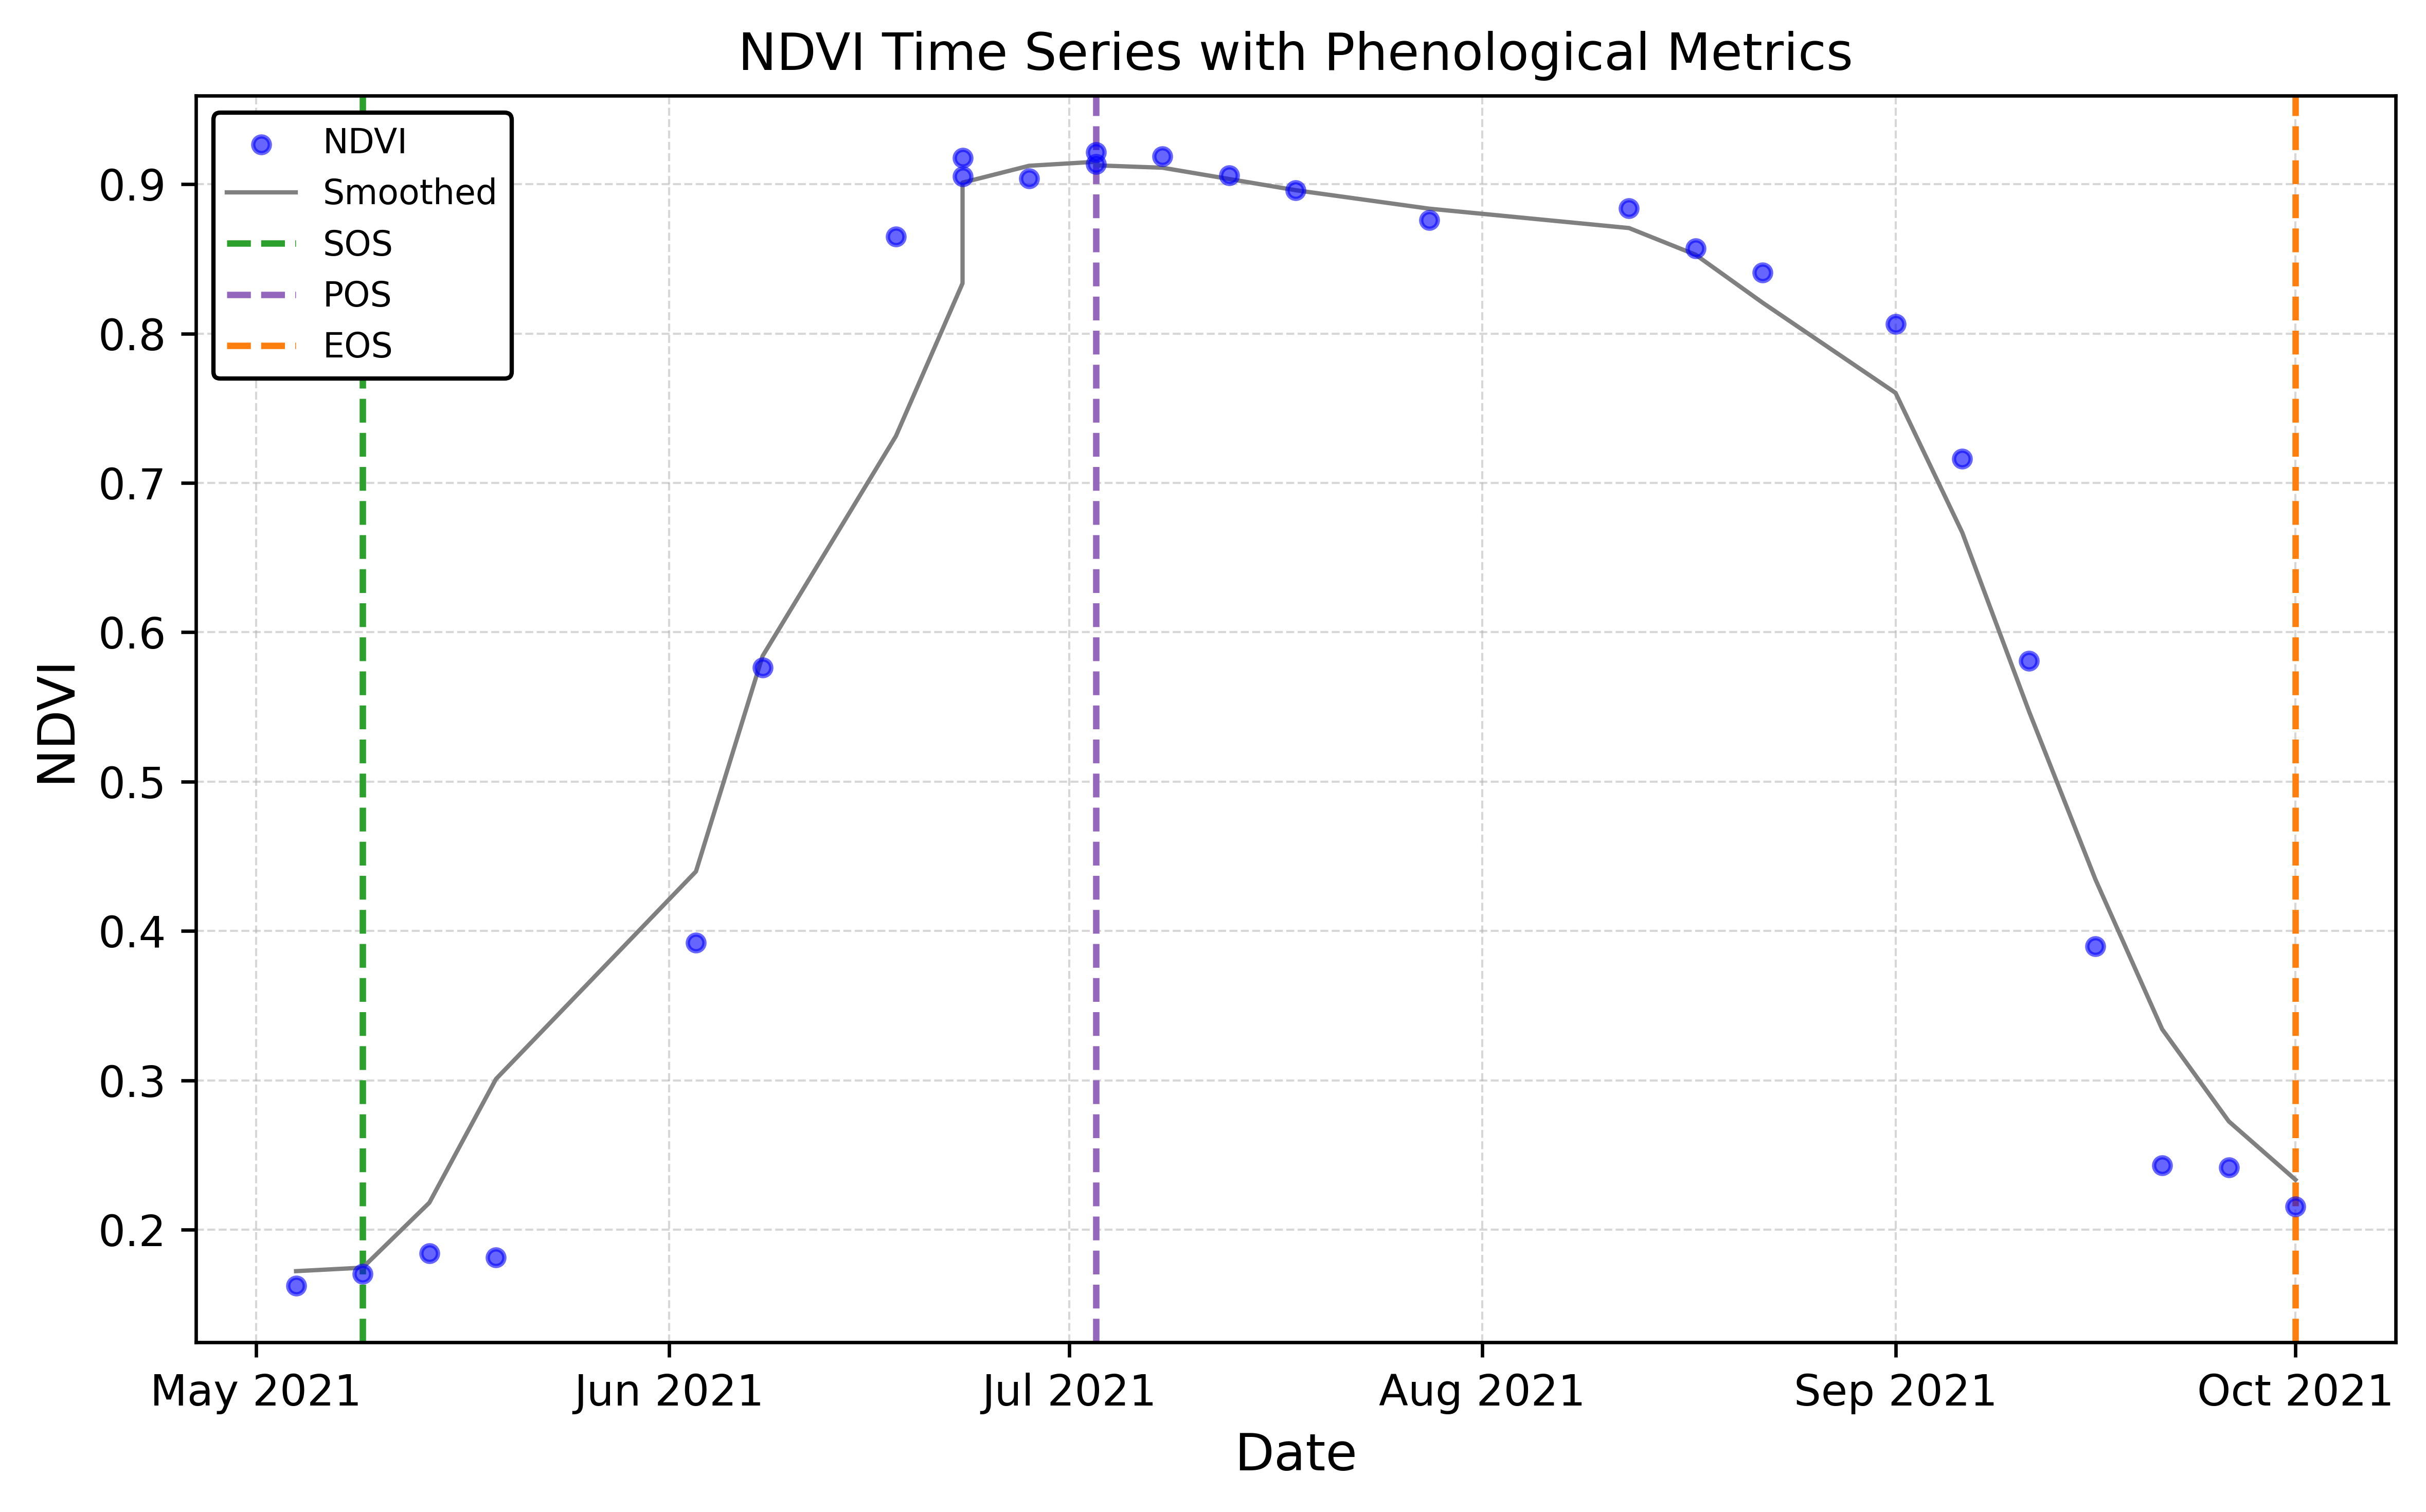

In [48]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.figure(figsize=(8,5), dpi=600)

# NDVI values
plt.scatter(
    series["date"],
    series["NDVI_original"],
    color='blue',
    s=15,
    alpha=0.6,
    label='NDVI',
    zorder=5
)

# Smoothed line
plt.plot(
    series["date"],
    series["NDVI_smoothed"],
    color='gray',
    linewidth=1,
    label="Smoothed",
    zorder=3
)

# Phenological metrics
plt.axvline(metrics["SOS_date"][0], color='#2ca02c', linestyle='--', linewidth=1.5, label='SOS')
plt.axvline(metrics["POS_date"][0], color='#9467bd', linestyle='--', linewidth=1.5, label='POS')
plt.axvline(metrics["EOS_date"][0], color='#ff7f0e', linestyle='--', linewidth=1.5, label='EOS')

# Labels
plt.xlabel("Date", fontsize=12)
plt.ylabel("NDVI", fontsize=12)
plt.title("NDVI Time Series with Phenological Metrics", fontsize=12)

# Grid
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)

# Date format
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())

# Legend
plt.legend(
    frameon=True,
    facecolor='white',
    edgecolor='black',
    framealpha=1,
    loc='upper left',
    fontsize=8
)

plt.tight_layout()

# Export
plt.savefig("ndvi_final_600dpi.png", dpi=600, bbox_inches='tight', facecolor='white')

plt.show()

In [49]:
from google.colab import files
files.download('ndvi_final_600dpi.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>